## Step 1: Imports & Setup

In [1]:
!pip install lightgbm xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve

import lightgbm as lgb
import xgboost as xgb

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

## Step 2: Load & Merge Data

In [3]:
import numpy as np
import pandas as pd
import gc

# Step 2a — Read a small sample first to detect column dtypes automatically
def get_dtypes(filepath, sample_size=10000):
    sample = pd.read_csv(filepath, nrows=sample_size)
    dtypes = {}
    for col in sample.columns:
        if sample[col].dtype == 'float64':
            dtypes[col] = 'float32'
        elif sample[col].dtype == 'int64':
            dtypes[col] = 'int32'
        else:
            dtypes[col] = sample[col].dtype
    return dtypes

# Step 2b — Build dtype maps for each file
train_transaction_dtypes = get_dtypes('train_transaction.csv')
train_identity_dtypes    = get_dtypes('train_identity.csv')
test_transaction_dtypes  = get_dtypes('test_transaction.csv')
test_identity_dtypes     = get_dtypes('test_identity.csv')

# Step 2c — Now read the FULL files using those lighter dtypes from the start
train_transaction = pd.read_csv('train_transaction.csv', dtype=train_transaction_dtypes)
train_identity    = pd.read_csv('train_identity.csv', dtype=train_identity_dtypes)
test_transaction  = pd.read_csv('test_transaction.csv', dtype=test_transaction_dtypes)
test_identity     = pd.read_csv('test_identity.csv', dtype=test_identity_dtypes)

print(f"train_transaction: {train_transaction.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"train_identity:    {train_identity.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"test_transaction:  {test_transaction.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"test_identity:     {test_identity.memory_usage(deep=True).sum()/1024**2:.1f} MB")

# Step 2d — Merge (same as before)
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_transaction if False else test_identity, on='TransactionID', how='left')

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print(f"\nTrain shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Fraud rate:  {train['isFraud'].mean():.4%}")

train_transaction: 935.5 MB
train_identity:    43.3 MB
test_transaction:  801.3 MB
test_identity:     42.3 MB

Train shape: (590540, 434)
Test shape:  (506691, 433)
Fraud rate:  3.4990%


## Step 3: EDA:- Target Imbalance & Key Distributions

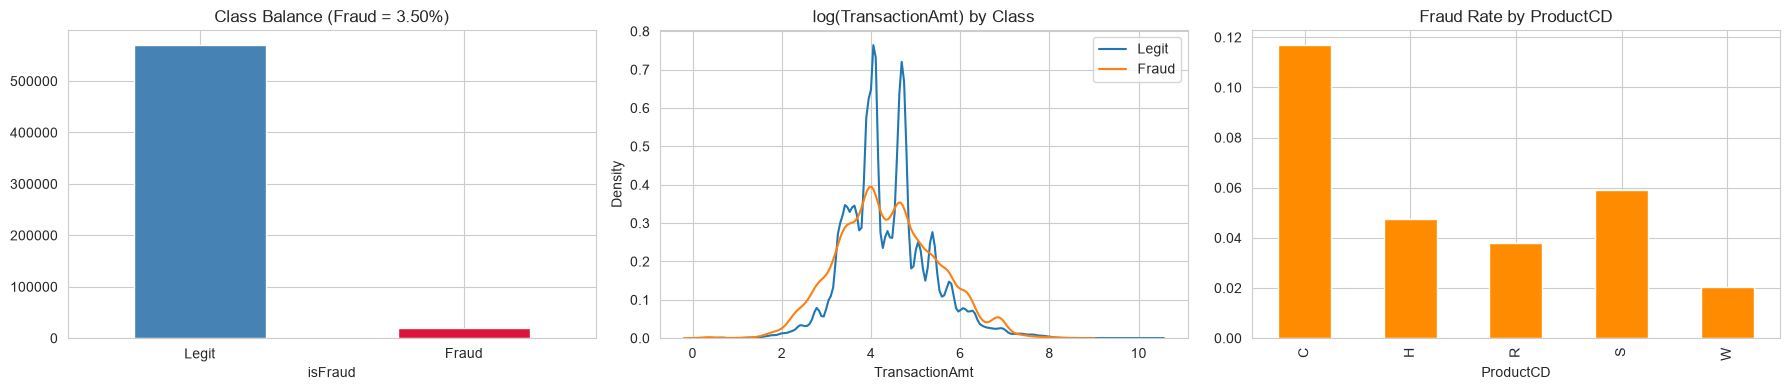

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 3a. Class imbalance
train['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title(f"Class Balance (Fraud = {train['isFraud'].mean():.2%})")
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

# 3b. TransactionAmt distribution (log scale, fraud vs legit)
sns.kdeplot(np.log1p(train.loc[train.isFraud==0, 'TransactionAmt']), ax=axes[1], label='Legit')
sns.kdeplot(np.log1p(train.loc[train.isFraud==1, 'TransactionAmt']), ax=axes[1], label='Fraud')
axes[1].set_title("log(TransactionAmt) by Class")
axes[1].legend()

# 3c. Fraud rate by ProductCD
train.groupby('ProductCD')['isFraud'].mean().plot(kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title("Fraud Rate by ProductCD")

plt.tight_layout()
plt.show()

## Step 4: EDA: Missing Values Map

Top 20 columns by missing %:
id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
id_10    0.873123
dtype: float64


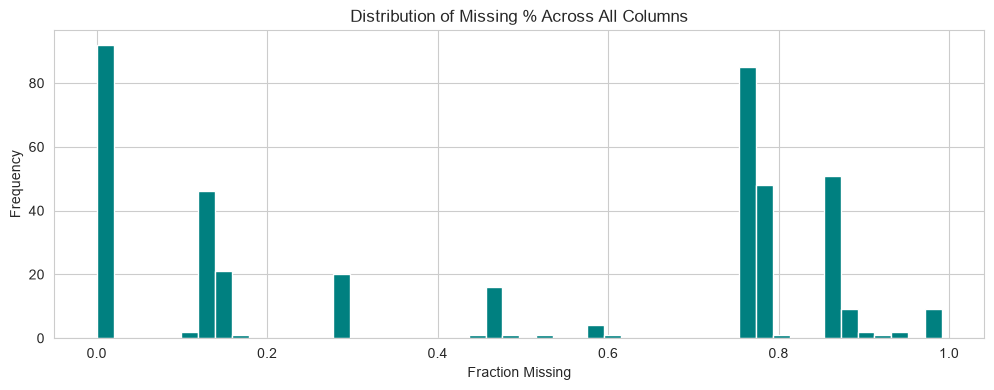


% of transactions with identity data: 24.42%


In [6]:
missing = train.isnull().mean().sort_values(ascending=False)
print("Top 20 columns by missing %:")
print(missing.head(20))

plt.figure(figsize=(12,4))
missing[missing > 0].plot(kind='hist', bins=50, color='teal')
plt.title("Distribution of Missing % Across All Columns")
plt.xlabel("Fraction Missing")
plt.show()

# Identity columns are only ~34% populated because most transactions have no identity match
print(f"\n% of transactions with identity data: {train['id_01'].notnull().mean():.2%}")

## Step 5: EDA:- Fraud Rate Over Time

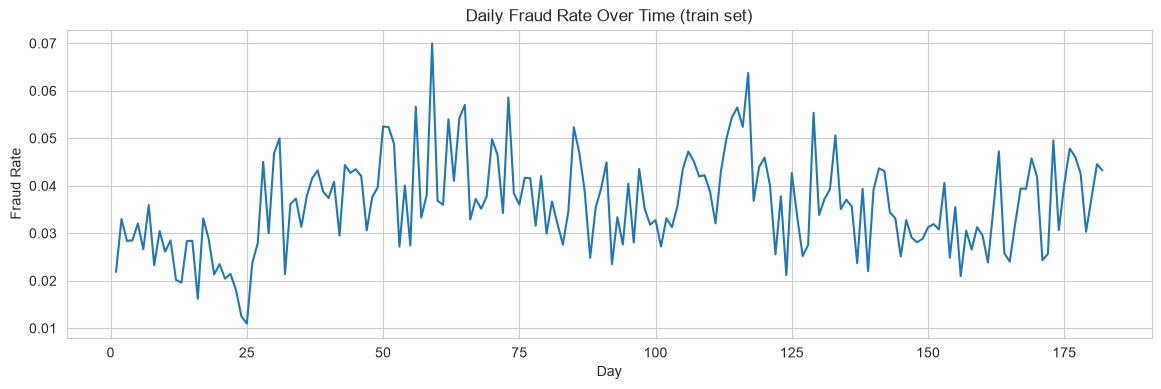

In [7]:
train['TransactionDT_days'] = train['TransactionDT'] / (3600*24)

daily_fraud = train.groupby(train['TransactionDT_days'].astype(int))['isFraud'].mean()

plt.figure(figsize=(14,4))
daily_fraud.plot()
plt.title("Daily Fraud Rate Over Time (train set)")
plt.xlabel("Day")
plt.ylabel("Fraud Rate")
plt.show()

## Step 6: Feature Engineering: Time & Amount

In [8]:
def engineer_time_amount_features(df):
    # Hour of day / day of week from TransactionDT (seconds since a reference point)
    df['Transaction_hour'] = (df['TransactionDT'] / 3600) % 24
    df['Transaction_day']  = (df['TransactionDT'] / (3600*24)) % 7

    # Decimal cents of amount — fraud often clusters at round numbers or unusual decimals
    df['TransactionAmt_decimal'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000).astype(int)

    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

    return df

train = engineer_time_amount_features(train)
test  = engineer_time_amount_features(test)

## Step 7: Feature Engineering: Card/Address Aggregations & Frequency Encoding

In [9]:
def frequency_encode(train_df, test_df, col):
    freq = train_df[col].value_counts(dropna=False)
    train_df[col + '_freq'] = train_df[col].map(freq)
    test_df[col + '_freq']  = test_df[col].map(freq)
    return train_df, test_df

freq_cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
for col in freq_cols:
    train, test = frequency_encode(train, test, col)

# Aggregated TransactionAmt stats per card1 (proxy for "customer" spending profile)
for agg in ['mean', 'std']:
    agg_map = train.groupby('card1')['TransactionAmt'].agg(agg)
    train[f'card1_TransactionAmt_{agg}'] = train['card1'].map(agg_map)
    test[f'card1_TransactionAmt_{agg}']  = test['card1'].map(agg_map)

# Deviation of this transaction from the card's typical amount — strong fraud signal
train['TransactionAmt_to_mean_card1'] = train['TransactionAmt'] / train['card1_TransactionAmt_mean']
test['TransactionAmt_to_mean_card1']  = test['TransactionAmt'] / test['card1_TransactionAmt_mean']

## Step 8: Feature Engineering: Email Domains & Categorical Encoding

In [10]:
def parse_email(df, col):
    df[col + '_bin'] = df[col].str.split('.').str[0]
    df[col + '_suffix'] = df[col].str.split('.').str[-1]
    return df

for col in ['P_emaildomain', 'R_emaildomain']:
    train = parse_email(train, col)
    test  = parse_email(test, col)

# Identify all categorical (object) columns for label encoding
cat_cols = [c for c in train.columns if train[c].dtype == 'object']
print(f"Categorical columns to encode: {len(cat_cols)}")

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

Categorical columns to encode: 4


## Step 9: Time-Based Train/Validation Split (Critical Step)

In [11]:
# Sort by time and take the LAST 20% as validation — mimics real-world deployment
# (Random splits here leak future info and give falsely inflated validation scores)
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)

drop_cols = ['isFraud', 'TransactionID', 'TransactionDT', 'TransactionDT_days']
feature_cols = [c for c in train_sorted.columns if c not in drop_cols]

split_idx = int(len(train_sorted) * 0.8)
X_train = train_sorted.iloc[:split_idx][feature_cols]
y_train = train_sorted.iloc[:split_idx]['isFraud']
X_val   = train_sorted.iloc[split_idx:][feature_cols]
y_val   = train_sorted.iloc[split_idx:]['isFraud']

print(f"Train: {X_train.shape}, Fraud rate: {y_train.mean():.4%}")
print(f"Val:   {X_val.shape}, Fraud rate: {y_val.mean():.4%}")

Train: (472432, 450), Fraud rate: 3.5135%
Val:   (118108, 450), Fraud rate: 3.4409%


## Step 10: Model 1:- LightGBM (Primary Model)

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 256,
    'max_depth': -1,
    'learning_rate': 0.05,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'seed': 42,
    'n_jobs': -1
}

cat_cols = [
    'ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30',
    'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
    'DeviceType', 'DeviceInfo'
]

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

lgb_train_set = lgb.Dataset(X_train, y_train, categorical_feature=cat_cols)
lgb_val_set   = lgb.Dataset(X_val, y_val, reference=lgb_train_set)

lgb_model = lgb.train(
    lgb_params,
    lgb_train_set,
    num_boost_round=3000,
    valid_sets=[lgb_train_set, lgb_val_set],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.512388 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37349
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 449
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.993655	val's auc: 0.919001
[200]	train's auc: 0.998939	val's auc: 0.920605
[300]	train's auc: 0.999784	val's auc: 0.920675
Early stopping, best iteration is:
[223]	train's auc: 0.999274	va

## Step 11: Model 2:- XGBoost (Comparison Model)

In [17]:
import gc, psutil

# --- diagnostics (just prints info, doesn't change anything) ---
print("Available RAM (GB):", psutil.virtual_memory().available / 1e9)
print("X_train memory (GB):", X_train.memory_usage(deep=True).sum() / 1e9)

# --- free memory from LightGBM objects if they still exist ---
for name in ['lgb_train_set', 'lgb_val_set']:
    if name in globals():
        del globals()[name]
gc.collect()

# --- downcast numeric columns to save memory ---
for col in X_train.select_dtypes(include=['float64']).columns:
    X_train[col] = X_train[col].astype('float32')
    X_val[col] = X_val[col].astype('float32')

for col in X_train.select_dtypes(include=['int64']).columns:
    X_train[col] = X_train[col].astype('int32')
    X_val[col] = X_val[col].astype('int32')

# --- unify categories across train and val ---
for col in cat_cols:
    all_categories = pd.concat([X_train[col], X_val[col]]).astype('category').cat.categories
    X_train[col] = pd.Categorical(X_train[col], categories=all_categories)
    X_val[col]   = pd.Categorical(X_val[col], categories=all_categories)

# --- xgboost params ---
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.05,
    'max_depth': 9,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    'max_cat_to_onehot': 4,
    'max_cat_threshold': 64,
    'max_bin': 256,
    'seed': 42
}

# --- memory-efficient DMatrix construction ---
dtrain = xgb.QuantileDMatrix(X_train, label=y_train, enable_categorical=True)
dval   = xgb.QuantileDMatrix(X_val, label=y_val, ref=dtrain, enable_categorical=True)

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=3000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=100,
    verbose_eval=100
)

Available RAM (GB): 0.480608256
X_train memory (GB): 0.836343908
[0]	train-auc:0.88002	val-auc:0.78994
[100]	train-auc:0.96955	val-auc:0.89787
[200]	train-auc:0.98619	val-auc:0.89912
[260]	train-auc:0.99099	val-auc:0.89858


Why not AdaBoost here: AdaBoost re-weights misclassified samples uniformly and struggles with the mix of high-cardinality categoricals + 339 correlated anonymized V features. It has no native missing-value handling either, so you'd need heavy imputation first, and it typically underperforms gradient boosting by a wide AUC margin on this exact dataset in published benchmarks. I'm skipping it for a reason, not by oversight — happy to add it if you want a baseline comparison anyway.

## Step 12: Evaluation: AUC, PR-AUC, Confusion Matrix

LightGBM: ROC-AUC = 0.92122 | PR-AUC = 0.57311
XGBoost: ROC-AUC = 0.90040 | PR-AUC = 0.49393


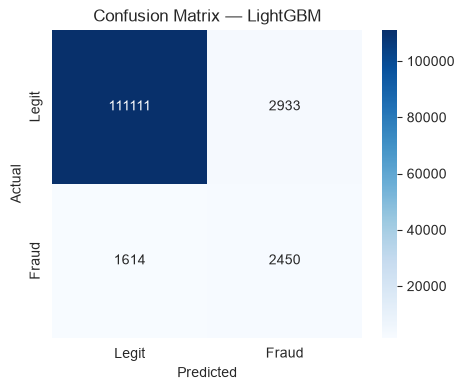

              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98    114044
       Fraud       0.46      0.60      0.52      4064

    accuracy                           0.96    118108
   macro avg       0.72      0.79      0.75    118108
weighted avg       0.97      0.96      0.96    118108



In [18]:
val_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
val_pred_xgb = xgb_model.predict(xgb.DMatrix(X_val), iteration_range=(0, xgb_model.best_iteration))

for name, preds in [('LightGBM', val_pred_lgb), ('XGBoost', val_pred_xgb)]:
    auc = roc_auc_score(y_val, preds)
    pr_auc = average_precision_score(y_val, preds)
    print(f"{name}: ROC-AUC = {auc:.5f} | PR-AUC = {pr_auc:.5f}")

# Confusion matrix at 0.5 threshold (LightGBM)
val_pred_binary = (val_pred_lgb > 0.5).astype(int)
cm = confusion_matrix(y_val, val_pred_binary)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title("Confusion Matrix — LightGBM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_val, val_pred_binary, target_names=['Legit','Fraud']))

## Step 13: ROC Curve Comparison

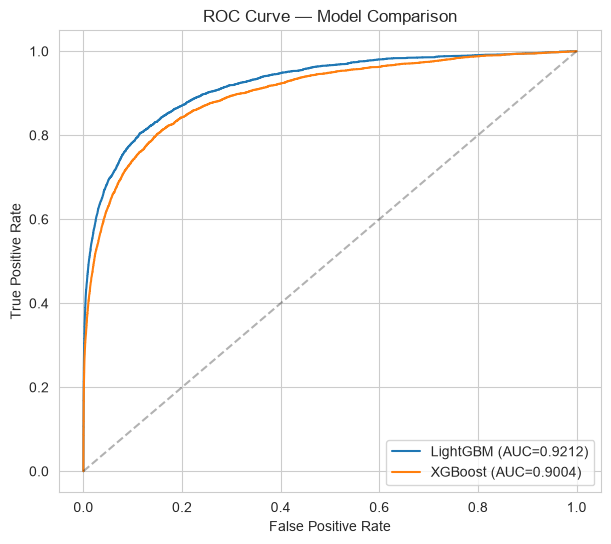

In [19]:
plt.figure(figsize=(7,6))
for name, preds in [('LightGBM', val_pred_lgb), ('XGBoost', val_pred_xgb)]:
    fpr, tpr, _ = roc_curve(y_val, preds)
    auc = roc_auc_score(y_val, preds)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison")
plt.legend()
plt.show()

## Step 14: Feature Importance & SHAP (Explainability)

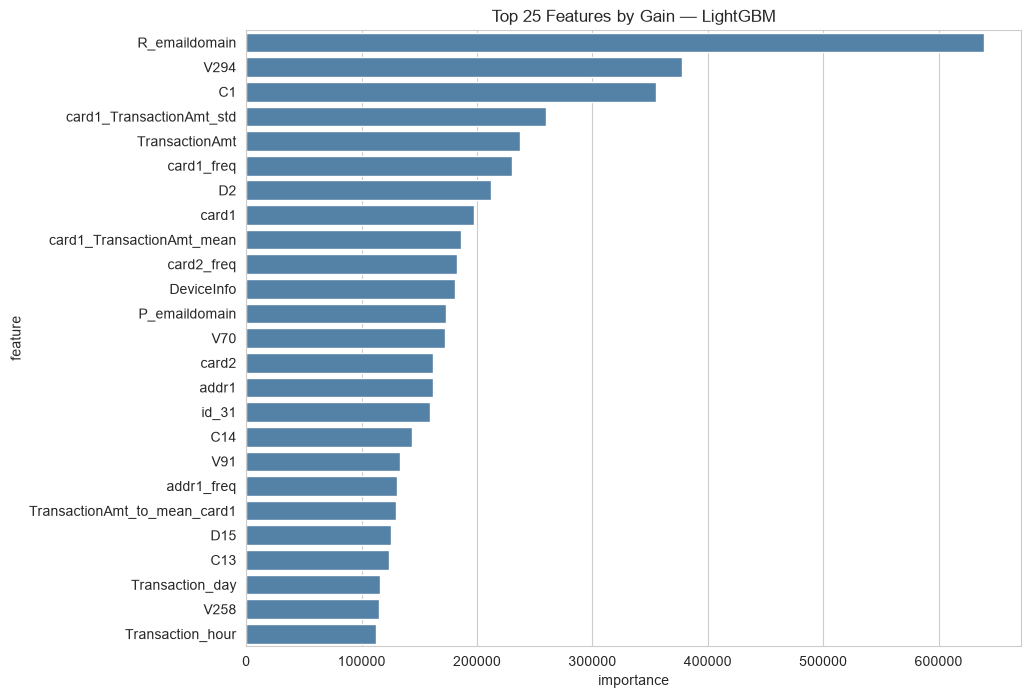

In [20]:
# LightGBM built-in importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10,8))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue')
plt.title("Top 25 Features by Gain — LightGBM")
plt.show()

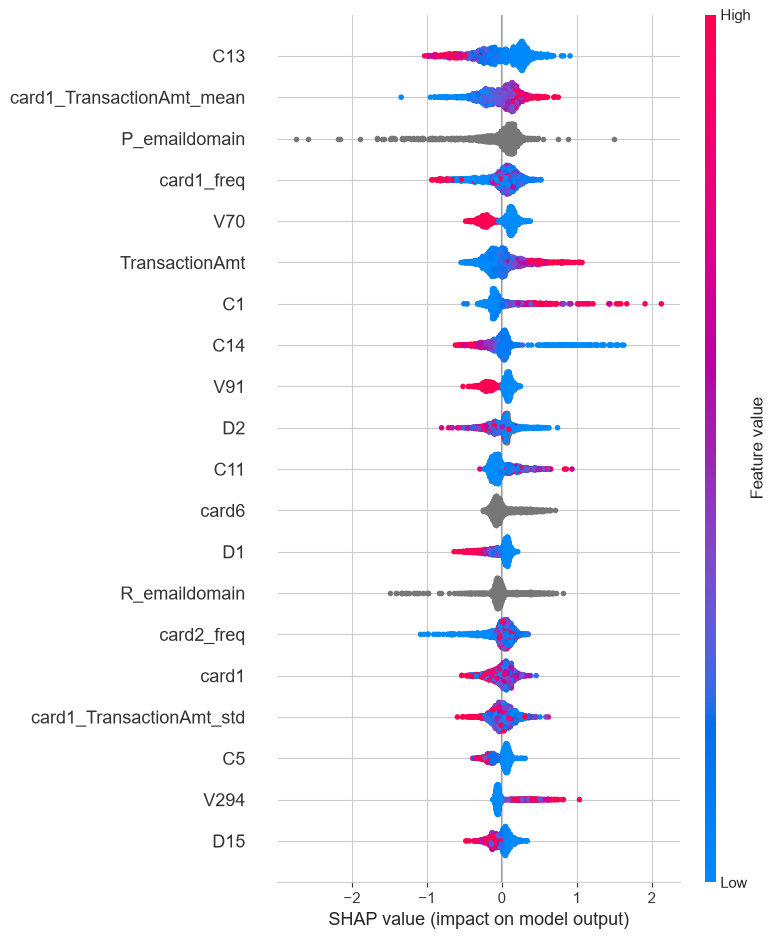

In [21]:
import shap

# SHAP on a sample for speed (SHAP on the full val set is slow)
sample_idx = np.random.choice(X_val.index, size=2000, replace=False)
X_sample = X_val.loc[sample_idx]

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=20)

## Step 15: Retrain on Full Data & Generate Test Predictions

In [26]:
import gc

# free memory from earlier models/datasets still lingering in RAM
for name in ['dtrain', 'dval', 'lgb_train_set', 'lgb_val_set', 'full_train_set']:
    if name in globals():
        del globals()[name]
gc.collect()

# downcast numeric columns in train_sorted and test to save memory
for col in train_sorted[feature_cols].select_dtypes(include=['float64']).columns:
    train_sorted[col] = train_sorted[col].astype('float32')
    if col in test.columns:
        test[col] = test[col].astype('float32')

for col in train_sorted[feature_cols].select_dtypes(include=['int64']).columns:
    train_sorted[col] = train_sorted[col].astype('int32')
    if col in test.columns:
        # use float32 instead of int32 if test has NaNs in this column (int can't hold NaN)
        if test[col].isna().any():
            test[col] = test[col].astype('float32')
        else:
            test[col] = test[col].astype('int32')

# fix column naming mismatch: test uses hyphens (id-12), train uses underscores (id_12)
test.columns = [c.replace('-', '_') for c in test.columns]

# convert categorical columns on the full train_sorted and test sets too
for col in cat_cols:
    all_categories = pd.concat([train_sorted[col], test[col]]).astype('category').cat.categories
    train_sorted[col] = pd.Categorical(train_sorted[col], categories=all_categories)
    test[col]         = pd.Categorical(test[col], categories=all_categories)

gc.collect()

# Retrain LightGBM on ALL labeled train data using the best_iteration found above
full_train_set = lgb.Dataset(train_sorted[feature_cols], train_sorted['isFraud'], categorical_feature=cat_cols)

final_model = lgb.train(
    lgb_params,
    full_train_set,
    num_boost_round=lgb_model.best_iteration
)

test_preds = final_model.predict(test[feature_cols])

submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.575323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42082
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 450
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


,TransactionID,isFraud
0,3663549,0.008023
1,3663550,0.005221
2,3663551,0.012870
3,3663552,0.005507
4,3663553,0.011637


## Step 16: (Optional but recommended) 5-Fold Time-Series CV for a More Robust Score

In [27]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(train_sorted)):
    X_tr, X_v = train_sorted.iloc[tr_idx][feature_cols], train_sorted.iloc[val_idx][feature_cols]
    y_tr, y_v = train_sorted.iloc[tr_idx]['isFraud'], train_sorted.iloc[val_idx]['isFraud']

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    params_fold = {**lgb_params, 'scale_pos_weight': spw}

    model_fold = lgb.train(
        params_fold,
        lgb.Dataset(X_tr, y_tr),
        num_boost_round=2000,
        valid_sets=[lgb.Dataset(X_v, y_v)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    preds = model_fold.predict(X_v, num_iteration=model_fold.best_iteration)
    score = roc_auc_score(y_v, preds)
    cv_scores.append(score)
    print(f"Fold {fold+1}: AUC = {score:.5f}")

print(f"\nMean CV AUC: {np.mean(cv_scores):.5f} ± {np.std(cv_scores):.5f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2529, number of negative: 95896
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.211326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35753
[LightGBM] [Info] Number of data points in the train set: 98425, number of used features: 448
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.025695 -> initscore=-3.635440
[LightGBM] [Info] Start training from score -3.635440
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[376]	valid_0's auc: 0.896934
Fold 1: AUC = 0.89693
[LightGBM] [Warning] Categorical features with more bins than 